In [30]:
import pandas as pd
from slugify import slugify
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
reader = pd.read_csv('datasets/bestsellers with categories.csv', chunksize=10000)
df = pd.concat(reader, ignore_index=True)
df.columns = df.columns.map(lambda x: slugify(x, separator='_'))
df.drop_duplicates(inplace=True)
df

,name,author,user_rating,reviews,price,year,genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction
...,...,...,...,...,...,...,...
545,Wrecking Ball (Diary of a Wimpy Kid Book 14),Jeff Kinney,4.9,9413,8,2019,Fiction
546,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2016,Non Fiction
547,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2017,Non Fiction
548,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2018,Non Fiction


In [3]:
df.head()

,name,author,user_rating,reviews,price,year,genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction


## Первинне дослідження даних

Перевірте, чи у всіх рядків вистачає даних: виведіть кількість пропусків (na) у кожному зі стовпців (використовуйте функції isna та sum)

Чи є в якихось змінних пропуски? (Так / ні) <br/> Відповідь: Ні

In [4]:
df.isna().sum().sort_values(ascending=False)

name           0
author         0
user_rating    0
reviews        0
price          0
year           0
genre          0
dtype: int64

Перевірте, які є унікальні значення в колонці genre (використовуйте функцію unique)

Які є унікальні жанри? <br/> Відповідь: ['Non Fiction', 'Fiction']

In [5]:
df['genre'].unique()

<StringArray>
['Non Fiction', 'Fiction']
Length: 2, dtype: str

Тепер подивіться на розподіл цін: побудуйте діаграму (використовуйте kind='hist')

<Axes: ylabel='Frequency'>

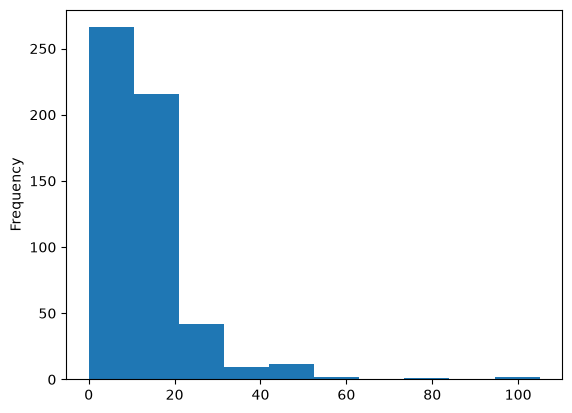

In [6]:
df['price'].plot(kind='hist')


Визначте, яка ціна у нас максимальна, мінімальна, середня, медіанна (використовуйте функції max, min, mean, median)


Максимальна ціна? <br/> Відповідь: 105


Мінімальна ціна? <br/> Відповідь: 1


Середня ціна? <br/> Відповідь: 13.1


Медіанна ціна? <br/> Відповідь: 11

In [7]:
# Ціну нуль важатимето за невалідну. Записи з ціною нуль видалеми
df.drop(df[df.price == 0].index, inplace=True)
df['price'].describe()

count    538.000000
mean      13.392193
std       10.782447
min        1.000000
25%        7.000000
50%       11.000000
75%       16.000000
max      105.000000
Name: price, dtype: float64

## Пошук та сортування даних

Який рейтинг у датасеті найвищий? <br/>
Відповідь: 4.9

In [8]:
df['user_rating'].sort_values(ascending=False).head(1)

431    4.9
Name: user_rating, dtype: float64

Скільки книг мають такий рейтинг? <br/>
Відповідь: 52

In [9]:
df['user_rating'][df.user_rating == 4.9].count()

np.int64(51)

Яка книга має найбільше відгуків? <br/>
Відповідь: Publication Manual of the American Psychological Association, 6th Edition, 10 reviews

In [24]:
df.groupby('name').agg(
    count_reviews=('user_rating', 'count')
).sort_values(by='count_reviews', ascending=False).head(1)

,count_reviews
name,
"Publication Manual of the American Psychological Association, 6th Edition",10


З тих книг, що потрапили до Топ-50 у 2015 році, яка книга найдорожча (можна використати проміжний датафрейм)? <br/>
Відповідь: Publication Manual of the American Psychological Association, 6th Edition

In [11]:
df[df.year==2015].sort_values(by='price', ascending=False).head(1)

,name,author,user_rating,reviews,price,year,genre
277,Publication Manual of the American Psychologic...,American Psychological Association,4.5,8580,46,2015,Non Fiction


Скільки книг жанру Fiction потрапили до Топ-50 у 2010 році (використовуйте &)? <br/>
Відповідь: 20

In [12]:
df[(df.year == 2010) & (df.genre == 'Fiction')]['name'].count()

np.int64(19)

Скільки книг з рейтингом 4.9 потрапило до рейтингу у 2010 та 2011 роках (використовуйте | або функцію isin)? <br/>
Відповідь: 1

In [13]:
df[(df.user_rating == 4.9) & (df.year.isin([2010, 2011]))]['name'].count()

np.int64(1)

І насамкінець, давайте відсортуємо за зростанням ціни всі книги, які потрапили до рейтингу в 2015 році і коштують дешевше за 8 доларів (використовуйте функцію sort_values).

Яка книга остання у відсортованому списку? <br/>
Відповідь: Old School (Diary of a Wimpy Kid #10)

In [14]:
df[(df.year == 2015) & (df.price < 8)].sort_values(by='price', ascending=True).tail(1)

,name,author,user_rating,reviews,price,year,genre
253,Old School (Diary of a Wimpy Kid #10),Jeff Kinney,4.8,6169,7,2015,Fiction


## Агрегування даних та з'єднання таблиць

Для початку давайте подивимося на максимальну та мінімальну ціни для кожного з жанрів (використовуйте функції groupby та agg, для підрахунку мінімальних та максимальних значень використовуйте max та min). Не беріть усі стовпці, виберіть тільки потрібні вам

In [15]:
df.groupby('genre').agg(
    max_price=('price', 'max'),
    min_price=('price', 'min')
)

,max_price,min_price
genre,,
Fiction,82,2
Non Fiction,105,1


Максимальна ціна для жанру Fiction: <br/>
Відповідь: 82

Мінімальна ціна для жанру Fiction: <br/>
Відповідь: 2

Мінімальна ціна для жанру Non Fiction: <br/>
Відповідь: 105

Максимальна ціна для жанру Non Fiction: <br/>
Відповідь: 1

Тепер створіть новий датафрейм, який вміщатиме кількість книг для кожного з авторів (використовуйте функції groupby та agg, для підрахунку кількості використовуйте count). Не беріть усі стовпці, виберете тільки потрібні

In [16]:
books_by_author = df.groupby('author').agg(
    count_books=('name', 'count')
).sort_values(by='count_books', ascending=False)
books_by_author

,count_books
author,
Gary Chapman,11
Rick Riordan,11
Suzanne Collins,11
American Psychological Association,10
Dr. Seuss,9
...,...
David Goggins,1
David Grann,1
Larry Schweikart,1


Якої розмірності вийшла таблиця? <br/>
Відповідь: (245, 1)

Який автор має найбільше книг? <br/>
Відповідь: Gary Chapman, Rick Riordan та Suzanne Collins

Скільки книг цього автора? <br/>
Відповідь: 11

In [17]:
books_by_author.shape

(245, 1)

Тепер створіть другий датафрейм, який буде вміщати середній рейтинг для кожного автора (використовуйте функції groupby та agg, для підрахунку середнього значення використовуйте mean). Не беріть усі стовпці, виберете тільки потрібні

In [18]:
rate_by_author = df.groupby('author').agg(
    avg_rating=('user_rating', 'mean')
).sort_values(by='avg_rating', ascending=False)
rate_by_author

,avg_rating
author,
Lin-Manuel Miranda,4.9
Rush Limbaugh,4.9
Dav Pilkey,4.9
Patrick Thorpe,4.9
Eric Carle,4.9
...,...
Pierre Dukan,4.1
Muriel Barbery,4.0
Gallup,4.0


Відповідь: У якого автора середній рейтинг мінімальний? <br/>
Відповідь: Donna Tartt

Відповідь: Який у цього автора середній рейтинг? <br/>
Відповідь: 3.9

In [19]:
rate_by_author.sort_values(by='avg_rating', ascending=True).head(1)

,avg_rating
author,
Donna Tartt,3.9


З'єднайте останні два датафрейми так, щоб для кожного автора було видно кількість книг та середній рейтинг (Використовуйте функцію concat з параметром axis=1). Збережіть результат у змінну

In [20]:
stats_by_author = pd.concat([books_by_author, rate_by_author], axis=1)
stats_by_author.head()

,count_books,avg_rating
author,,
Gary Chapman,11,4.736364
Rick Riordan,11,4.772727
Suzanne Collins,11,4.663636
American Psychological Association,10,4.500000
Dr. Seuss,9,4.877778


Відсортуйте датафрейм за зростаючою кількістю книг та зростаючим рейтингом (використовуйте функцію sort_values)

Який автор перший у списку? <br/>
Відповідь: Muriel Barbery, books: 1, avg_rating: 4.0

In [21]:
stats_by_author.sort_values(by=['count_books', 'avg_rating'], ascending=[True, True]).head(1)

,count_books,avg_rating
author,,
Muriel Barbery,1,4.0


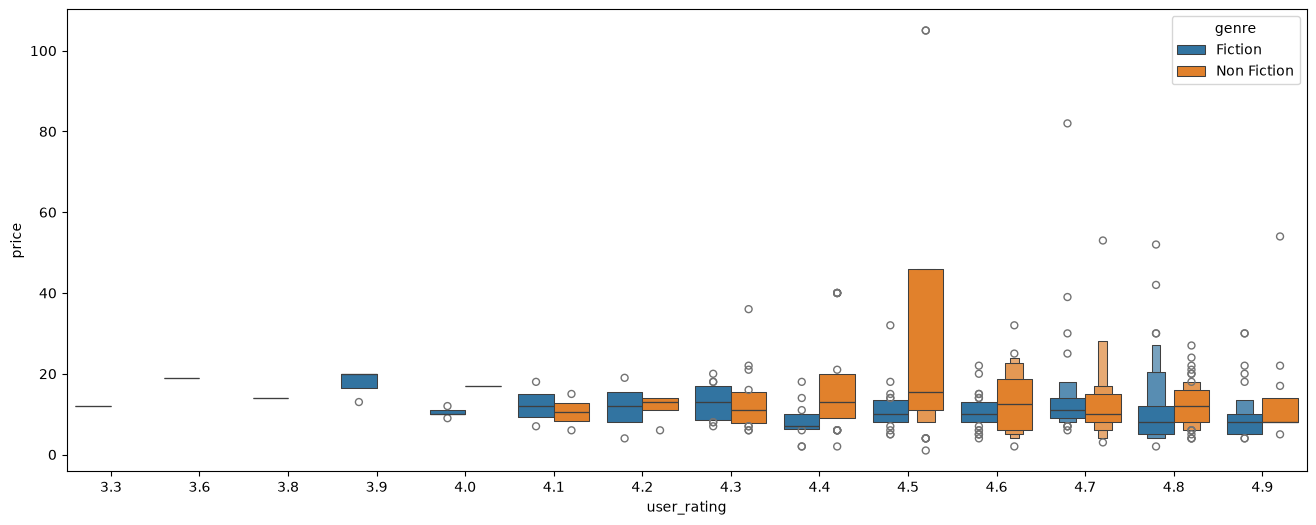

In [38]:
plot_data = df[['user_rating', 'price', 'reviews', 'genre']]

fig, ax = plt.subplots(figsize=(16, 6))
ax = sns.boxenplot(x="user_rating", y="price", hue='genre', data=plot_data)

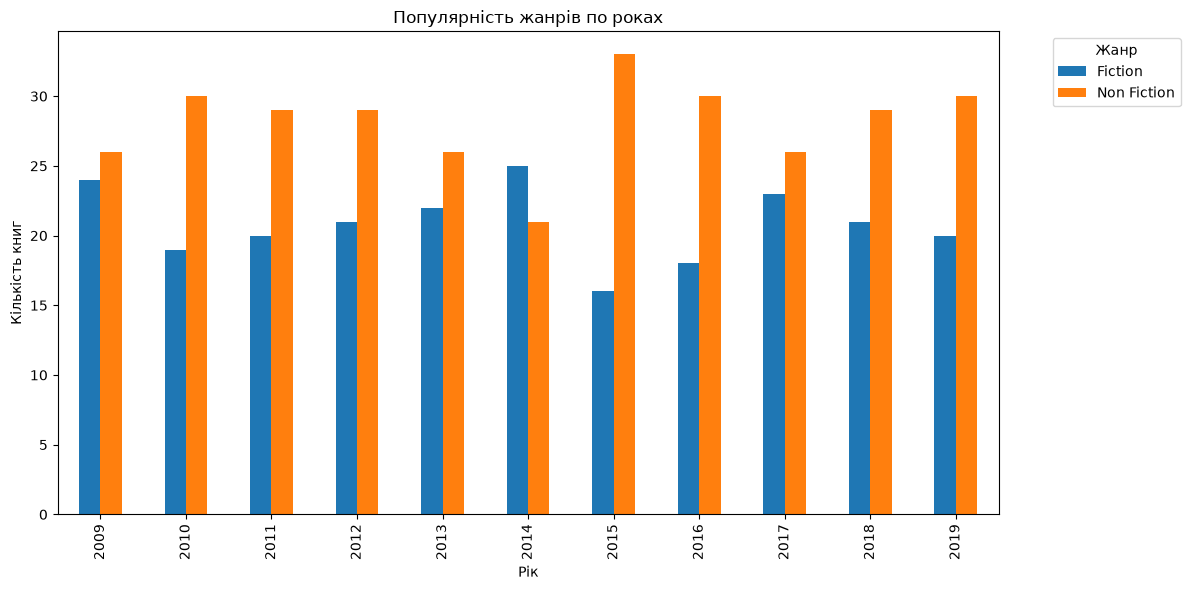

In [54]:
genre_by_year = df.groupby(['year', 'genre']).size().reset_index(name='count')
genre_by_year = genre_by_year.pivot(index='year', columns='genre', values='count').fillna(0)

genre_by_year.plot(figsize=(12, 6), kind='bar')
plt.title('Популярність жанрів по роках')
plt.xlabel('Рік')
plt.ylabel('Кількість книг')
plt.legend(title='Жанр', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()